In [ ]:
Satellite-Based Crop Health Prediction

In [ ]:
pip install shap

In [ ]:
pip install xgboost

In [181]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.9 MB/s eta 0:00:55
   ---------------------------------------- 1.0/101.7 MB 2.1 MB/s eta 0:00:48
    --------------------------------------- 1.6/101.7 MB 2.1 MB/s eta 0:00:47
    --------------------------------------- 1.6/101.7 MB 2.1 MB/s eta 0:00:47
    --------------------------------------- 1.6/101.7 MB 2.1 MB/s eta 0:00:47
    --------------------------------------- 1.6/101.7 MB 2.1 MB/s eta 0:00:47
    --------------------------------------- 1.6/101.7 MB 2.1 MB/s eta 0:00:47
    --------------------------------------- 1.6/101.7 MB 2.1 MB/s eta 0:00:47
    --------------------------------------- 1.6/101.7 MB 2.1 MB/s eta 0:00:47
    --------------------------------------- 1.6/101.7 MB 2.1 MB/s eta 0:00:47
    ---

In [183]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from xgboost import XGBClassifier

### Create artificial satellite dataset → train ML model


In [ ]:
# Set seed for reproducibility
np.random.seed(42)

# Data size
data_size = 500

# Generate random data
ndvi = np.random.uniform(0.1, 0.9, data_size)
temp = np.random.uniform(20, 40, data_size)
humidity = np.random.uniform(40, 90, data_size)
ndwi = np.random.uniform(0.1, 0.5, data_size)
ndmi = np.random.uniform(0.1, 0.6, data_size)

# Label logic (optimized using list comprehension)
labels = [
    "Healthy" if ndvi[i] > 0.6 and humidity[i] > 70
    else "Stressed" if ndvi[i] > 0.3
    else "Unhealthy"
    for i in range(data_size)
]

# Create DataFrame
df = pd.DataFrame({
    "NDVI": ndvi,
    "Temperature": temp,
    "Humidity": humidity,
    "NDWI": ndwi,
    "NDMI": ndmi,
    "Label": labels
})

# Save dataset
df.to_csv("crop_health_data.csv", index=False)

print("Dataset created successfully!")
print(df.head())

### Data Analysis (EDA) & Model Training

In [271]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\XBOSON AI\crop_health_data.csv")
df.head()

,NDVI,Temperature,Humidity,NDWI,NDMI,Label
0,0.399632,33.963234,49.256646,0.307633,0.230853,Stressed
1,0.860571,30.721927,67.095047,0.291673,0.223489,Stressed
2,0.685595,26.190552,83.647292,0.110257,0.553127,Healthy
3,0.578927,36.275900,76.611244,0.236499,0.224773,Stressed
4,0.224815,33.694623,80.328057,0.252078,0.235975,Unhealthy


### Sources of Crop Data

| Source      | Data                  |
| ----------- | --------------------- |
| Satellite   | NDVI, NDWI, NDMI      |
| Weather API | Temperature, Humidity |


### NDVI = Normalized Difference Vegetation Index
It tells:

How healthy and green the plants are


#### How NDVI is calculated

It uses satellite data:

NIR (Near Infrared)

Red light

NDVI= NIR−Red / NIR + Red 


##### Imagine looking at a farm from satellite:

Dark green → high NDVI (healthy crops)

Light green / brown → low NDVI (stressed crops)


| NDVI Value | Meaning           |
| ---------- | ----------------- |
| 0.1 – 0.3  | Poor vegetation  |
| 0.3 – 0.6  | Moderate        |
| 0.6 – 0.9  | Healthy        |


### NDWI = Normalized Difference Water Index
It tells:

##### How much water is present in plants or land

Low NDWI → dry soil / stressed plants

Medium NDWI → normal condition

High NDWI → good water availability

##### How NDWI is calculated

NDWI = Green - NIR / Green + NIR

#### NDMI = Normalized Difference Moisture Index

How much moisture (water) is inside the plant leaves


##### How NDMI is calculated

NDMI = NIR - SWIR / NIR + SWIR


| NDMI Value | Meaning         |
| ---------- | --------------- |
| 0.1 – 0.2  | Low moisture   |
| 0.3 – 0.5  | Medium        |
| 0.5 – 0.6  | High moisture  |


#### Temperature = how hot or cold something is

| Range   | Meaning       |
| ------- | ------------- |
| 20–25°C | Very good    |
| 25–35°C | Good        |
| >35°C   | Stress      |
| <15°C   | Slow growth  |


### Humidity = how much water (moisture) is in the air

| Range  | Meaning                    |
| ------ | -------------------------- |
| 40–50% | Low (dry)                 |
| 50–70% | Good                      |
| 70–85% | High (okay)              |
| >85%   | Too humid (disease risk)  |


#### info

In [16]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   NDVI         500 non-null    float64
 1   Temperature  500 non-null    float64
 2   Humidity     500 non-null    float64
 3   NDWI         500 non-null    float64
 4   NDMI         500 non-null    float64
 5   Label        500 non-null    str    
dtypes: float64(5), str(1)
memory usage: 23.6 KB
None


#### describe

In [14]:
print(df.describe())

             NDVI  Temperature    Humidity        NDWI        NDMI
count  500.000000   500.000000  500.000000  500.000000  500.000000
mean     0.498849    29.639028   65.877906    0.298591    0.349922
std      0.238951     5.709869   14.859647    0.114804    0.142905
min      0.104049    20.092640   40.246999    0.101287    0.100783
25%      0.293024    24.581985   52.061402    0.196430    0.234056
50%      0.510531    29.436431   66.986917    0.303557    0.348006
75%      0.704900    34.526736   78.867188    0.394950    0.471647
max      0.894372    39.994353   89.970686    0.499339    0.597719


#### Standardization

In [18]:
cols = ['NDVI', 'Temperature', 'Humidity', 'NDWI', 'NDMI']

scaler = StandardScaler()

df[cols] = scaler.fit_transform(df[cols])

print(df.head())

       NDVI  Temperature  Humidity      NDWI      NDMI      Label
0 -0.415636     0.758080 -1.119670  0.078840 -0.834041   Stressed
1  1.515310     0.189844  0.081991 -0.060318 -0.885619   Stressed
2  0.782307    -0.604555  1.197012 -1.642125  1.423390    Healthy
3  0.335457     1.163515  0.723038 -0.541390 -0.876627   Stressed
4 -1.147973     0.710990  0.973416 -0.405552 -0.798162  Unhealthy


####  Standardization Formula

xnew ​= x−mean / std

Make all data centered and balanced using mean and std

#### Encoding
Converts text → numbers

In [114]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Label"] = le.fit_transform(df["Label"])

Example = {'Healthy': 0, 'Stressed': 1, 'Unhealthy': 2}

### Distribution of Features

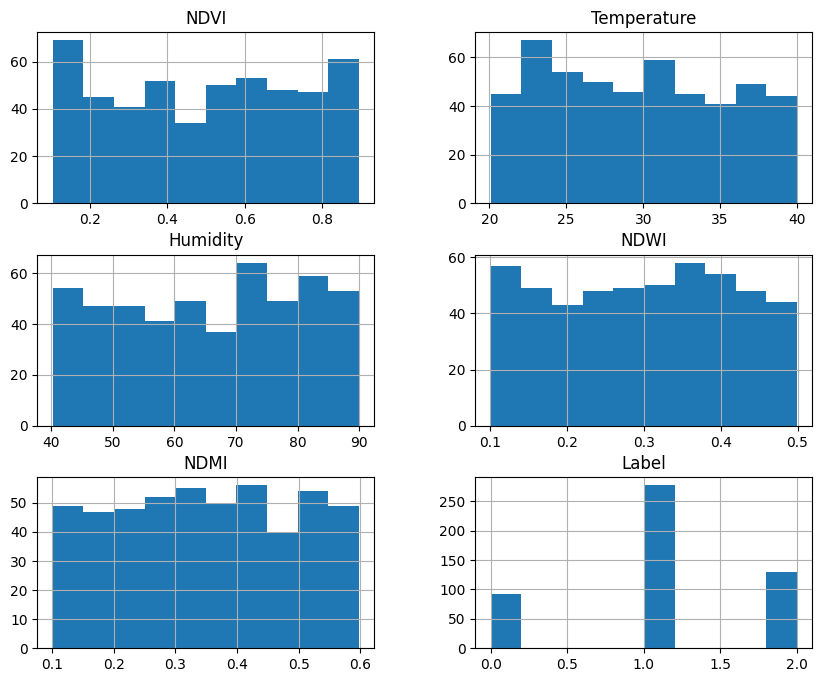

In [118]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

#### NDVI
Some crops have low NDVI (poor vegetation)

Some have medium NDVI

Some have high NDVI (healthy vegetation)


#### Temperatures

dataset has temperatures mostly between 25°C and 35°C

#### Humidity

Some dry conditions (40–50%)

Many medium conditions (60–80%)

Some very humid conditions (80–90%)

#### NDWI
Some low water conditions (0.1–0.2)

Many medium water conditions (0.3–0.4)

Few higher water conditions (near 0.5)


#### NDMI 

Some low moisture plants (0.1–0.2)

Many medium moisture plants (0.3–0.5)

Some high moisture plants (0.5–0.6)


### Class Distribution

In [120]:
print(df["Label"].value_counts())

Label
1    277
2    130
0     93
Name: count, dtype: int64


###### Most of your data is “Stressed”, so classes are imbalanced
use class_weight='balanced

### Correlation Analysis

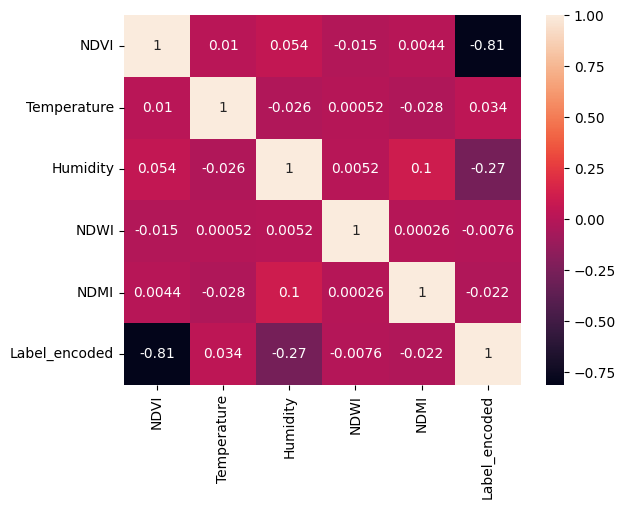

In [94]:
import seaborn as sns

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

#### It shows how strongly features are related to each other

Value close to 1 → strong positive relation 

Value close to -1 → strong negative relation

Value close to 0 → no relation 

Almost NO strong relationship between features


Example:

NDVI vs Temperature = 0.01

  No relation
  
Humidity vs NDMI = 0.1

  Very weak relation

##### Correlation shows how features are connected — your data has low correlation, so each feature gives unique information (good for your model)

 1. Avoid duplicate information

 If two columns are highly correlated:

They give same info

You can remove one

 In your case:
 No strong correlation
 All features are useful 


### Boxplot

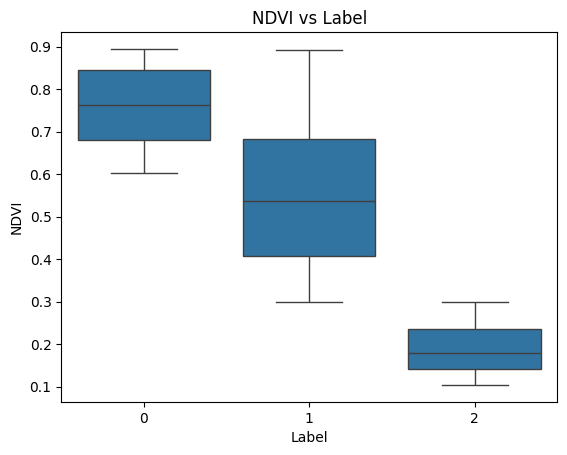

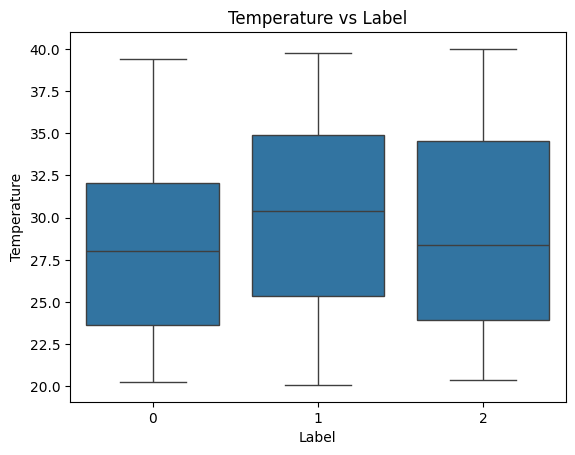

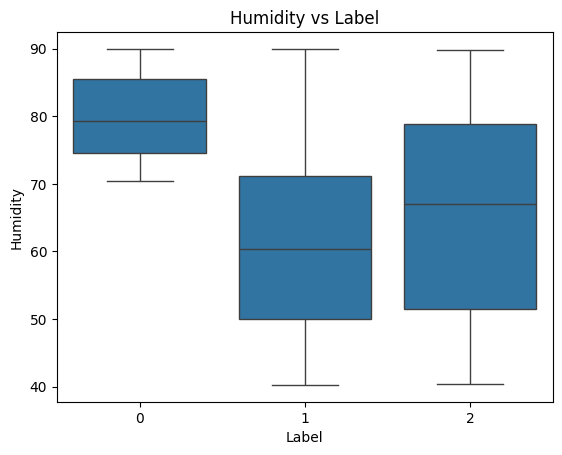

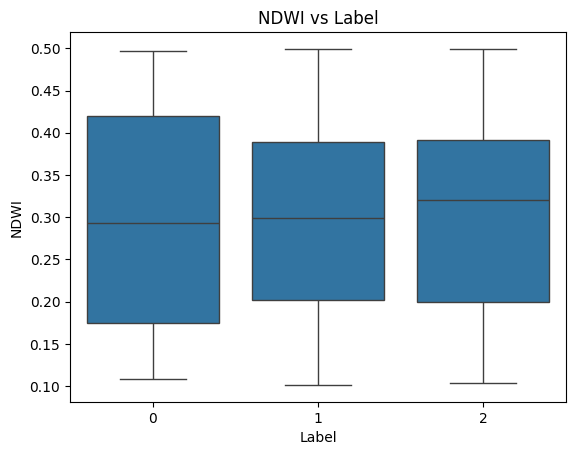

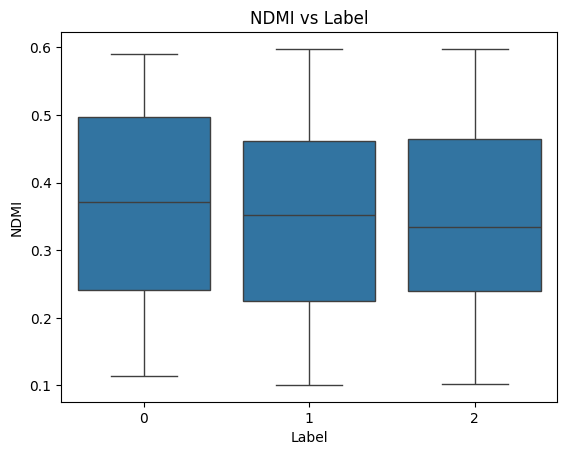

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['NDVI', 'Temperature', 'Humidity', 'NDWI', 'NDMI']

for feature in features:
    plt.figure()
    sns.boxplot(x='Label', y=feature, data=df)
    plt.title(f"{feature} vs Label")
    plt.show()

### 1.It compares NDVI values for each class:

##### Healthy

NDVI is high (~0.7–0.9)


##### Stressed

NDVI is medium (~0.4–0.7)

#####  Unhealthy

NDVI is low (~0.1–0.3)


### 2.It compares temperature values for each class:

All three groups have almost similar temperature range

Temperature works with other features like:

NDVI
NDMI
NDWI

### 3.It compares humidity values for each class:

Healthy

 Humidity is high (70–90%) 
 
 Plants grow well in moist air


Stressed

 Humidity is medium (50–70%)
 
 Not ideal → plants get stress

Unhealthy

 Humidity is mixed (40–90%)
 
 No clear pattern
 

### 4.It compares NDWI (water level) for each class:

All three groups have almost same range:

Around 0.1 to 0.5

Why:

NDWI alone cannot predict crop health

Needs combination like:NDVI,NDMI,Humidity

### 5.It compares NDMI (plant moisture)

All three classes have very similar values:

Range: 0.1 to 0.6

Medians are close (~0.33–0.37)

Why:

NDMI alone cannot predict crop health


It may still help when combined with:

NDVI
Humidity

### Prepare Data 

In [292]:
X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model 1 : Random Forest

In [294]:
rf_model = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)


Random Forest is used because it handles multiple features, gives accurate predictions, and works well for complex data

###  Performance

In [131]:
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


### Cross validation

In [252]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)
print(scores)

[0.99 0.99 0.99 0.99 1.  ]


Cross-validation shows my model performs consistently with ~99% accuracy across different data splits

In [257]:
print(scores.mean())

0.992


### Train & Test Accuracy

In [296]:
from sklearn.metrics import accuracy_score

# Train accuracy
rf_train_pred = rf_model.predict(X_train)
rf_train_acc = accuracy_score(y_train, rf_train_pred)

# Test accuracy
rf_test_pred = rf_model.predict(X_test)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

print("RF Train Accuracy:", rf_train_acc)
print("RF Test Accuracy:", rf_test_acc)

RF Train Accuracy: 1.0
RF Test Accuracy: 1.0


### Model predicted everything correctly

why:

The model achieved 100% accuracy due to simple synthetic data, which may not reflect real-world performance.

#### Feature Importance

This tells:

Which feature the model is using the most

In [135]:
importance = rf_model.feature_importances_

features = X.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(imp_df)

       Feature  Importance
0         NDVI    0.665409
2     Humidity    0.239565
3         NDWI    0.033672
1  Temperature    0.033426
4         NDMI    0.027928


NDVI is used more because it gives the most information about crop health

#### Visualize one tree

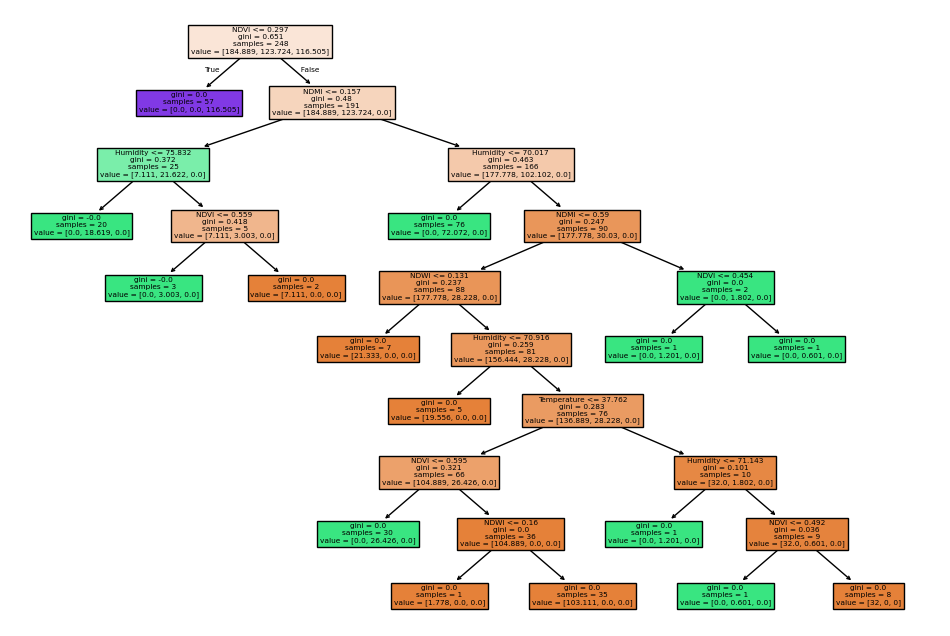

In [137]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(rf_model.estimators_[0], feature_names=X.columns, filled=True)
plt.show()

#### It shows how the model makes decisions step-by-step

Think of it like:

“IF-ELSE rules”

0.297 is a value automatically chosen by the model

 It is the best split point for separating the data

 Example path (simple)

 Suppose:

NDVI = 0.2

Humidity = 50

Then tree does:

1️ NDVI ≤ 0.297 → YES

2️ Go left

3️ Check next condition

4️ Continue…

 Finally reaches:

 Label = Unhealthy / Stressed / Healthy

In [139]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_pred))

[[18  0  0]
 [ 0 55  0]
 [ 0  0 27]]


### Model Evaluation

In [141]:
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

print("\nClassification Report (RF):")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0

Classification Report (RF):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        55
           2       1.00      1.00      1.00        27

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



##### 1. Precision 

 Precision = How many predicted are actually correct

Simple:

 “When model says YES, how often is it correct?”

Example:

Model says 10 are Healthy

Actually correct = 8

 Precision = 8/10 = 0.8

##### 2. Recall 

 Recall = How many actual cases are found

Simple:

 “Out of all real cases, how many did model find?”

Example:
Actual Healthy = 10
Model found = 8

 Recall = 8/10 = 0.8

##### 3. F1-score 

 F1 = balance of precision + recall

Simple:

 “Overall performance”

 High F1 = good model

#####  4. Support 

 Support = number of actual samples

Example:

Healthy → 18 samples
Stressed → 55

### Give new input to model

In [143]:
# Example new data
new_data = [[0.18  ,  37.5   ,       50.2   ,    0.20  ,  0.22  ]]  

prediction = rf_model.predict(new_data)

print("Predicted Label:", prediction)

Predicted Label: [2]


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Good prediction

{'Healthy': 0, 'Stressed': 1, 'Unhealthy': 2}

### Model 2: Support Vector Machine (SVM)

It is used to separate different groups (classes)


In [269]:
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.56


### Visualization

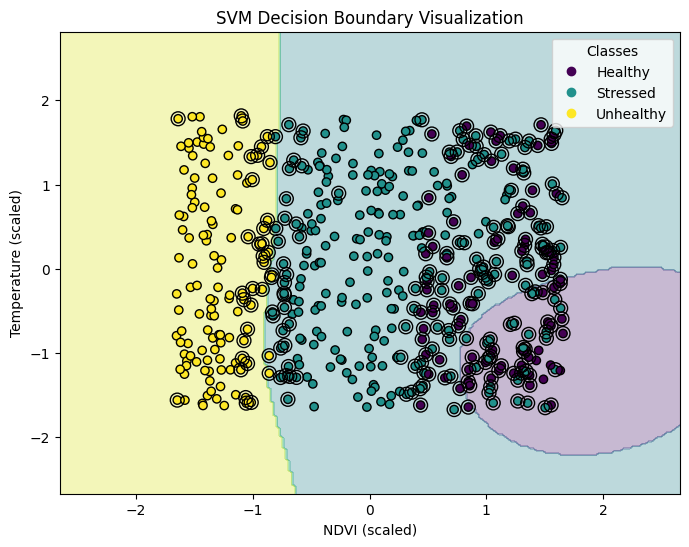

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder

#  1. Select only 2 features for visualization
X_vis = df[["NDVI", "Temperature"]]
y_vis = df["Label"]

#  2. Encode labels (IMPORTANT)
le = LabelEncoder()
y_encoded = le.fit_transform(y_vis)

#  3. Scale features (VERY IMPORTANT for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

#  4. Train SVM model
model = SVC(kernel='rbf')
model.fit(X_scaled, y_encoded)

#  5. Create mesh grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

#  6. Predict for grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

#  7. Plot decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

#  8. Plot actual data points
scatter = plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_encoded,
    edgecolors='k'
)

#  9. Plot support vectors (VERY IMPORTANT )
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=100,
    facecolors='none',
    edgecolors='black',
    label="Support Vectors"
)

#  10. Labels & title
plt.xlabel("NDVI (scaled)")
plt.ylabel("Temperature (scaled)")
plt.title("SVM Decision Boundary Visualization")

#  11. Legend (convert numbers back to labels)
handles, _ = scatter.legend_elements()
labels = le.classes_
plt.legend(handles, labels, title="Classes")

plt.show()

Model is learning, but not separating classes clearly

### Model Evaluation

In [75]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_acc)

# Classification Report
print("\nClassification Report (SVM):")
print(classification_report(y_test, svm_pred))


SVM Accuracy: 0.56

Classification Report (SVM):
              precision    recall  f1-score   support

     Healthy       0.31      0.50      0.38        18
    Stressed       0.66      0.85      0.75        55
   Unhealthy       0.00      0.00      0.00        27

    accuracy                           0.56       100
   macro avg       0.32      0.45      0.38       100
weighted avg       0.42      0.56      0.48       100



C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Model ignores Unhealthy class and mostly predicts Stressed

In [77]:
# Confusion Matrix
print("\nConfusion Matrix (SVM):")
print(confusion_matrix(y_test, svm_pred))


Confusion Matrix (SVM):
[[ 9  9  0]
 [ 8 47  0]
 [12 15  0]]


Model is ignoring the Unhealthy class completely

### Prediction

In [275]:
# Example new data
new_data = [[0.18  ,  37.5   ,       50.2   ,    0.20  ,  0.22  ]]  


prediction = svm_model.predict(new_data)

print("Predicted Label:", prediction)

Predicted Label: [1]


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Wrong predictions on unhealthy values.

{'Healthy': 0, 'Stressed': 1, 'Unhealthy': 2

### Model 3: XGBoost

In [248]:
# Model
xgb_model = XGBClassifier(
    max_depth=3,
    n_estimators=100,
    learning_rate=0.1,
    reg_alpha=1,
    reg_lambda=1
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


### Save model

In [307]:
import pickle

pickle.dump(xgb_model, open("xgb_model.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!


### label_encoder.pkl

In [309]:
import pickle

pickle.dump(le, open("label_encoder.pkl", "wb"))

print("Label encoder saved!")

Label encoder saved!


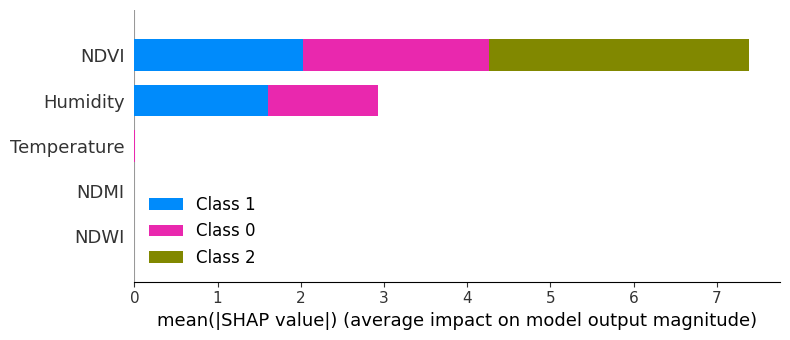

In [218]:
import shap

# Create explainer
explainer = shap.Explainer(xgb_model)

# Get SHAP values
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

NDVI is the main feature driving predictions, while other features have little impact.”

### Model Evaluation

In [225]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
xgb_acc = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", xgb_acc)

# Classification Report
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, xgb_pred))


XGBoost Accuracy: 1.0

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        55
           2       1.00      1.00      1.00        27

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



The model achieved 100% accuracy due to synthetic rule-based data, which may indicate overfitting

In [227]:
# Confusion Matrix (optional)
print("\nConfusion Matrix (XGBoost):")
print(confusion_matrix(y_test, xgb_pred))


Confusion Matrix (XGBoost):
[[18  0  0]
 [ 0 55  0]
 [ 0  0 27]]


### Cross-validation

In [230]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X, y, cv=5)
print(scores)

[0.97 0.99 1.   0.99 1.  ]


In [232]:
print(scores.mean())

0.99


Cross-validation shows my model performs consistently with ~99% accuracy across different data splits.”

### Model predicted everything correctly

why:

The model achieved 100% accuracy due to simple synthetic data, which may not reflect real-world performance.

### Prediction

In [262]:
# Example new data
new_data = [[0.18  ,  37.5   ,       50.2   ,    0.20  ,  0.22  ]]  


prediction = xgb_model.predict(new_data)

print("Predicted Label:", prediction)

Predicted Label: [2]


Good prediction

{'Healthy': 0, 'Stressed': 1, 'Unhealthy': 2

## Simple explanation

### 1.Why i'm using Random Forest (RF)

Because it gives better accuracy and handles complex data well

1. Handles complex relationships

  data is not simple:

NDVI + humidity + temp → mixed effect

 RF can:
 Capture complex patterns easily

Gives feature importance

Which feature is important

rf_model.feature_importances_

RF = many trees 

 Combines results → more stable

It creates many decision trees:

Final output:
 Majority vote

I used Random Forest because it handles non-linear relationships, works well with multiple features, and provides better accuracy compared to SVM for my dataset.

### 2.Why i'm using SVM 

To separate crop conditions (Healthy / Stressed / Unhealthy)

This is a classification problem

 SVM is designed for:

 Classification

SVM (RBF kernel) can:

 Create curved boundaries

SVM learns patterns like:

High NDVI + high humidity → Healthy

Low NDVI → Unhealthy

 Then predicts new data

I used SVM as a baseline model to classify crop health based on satellite-derived features. It helps in understanding data separability, though other models may perform better.

### 3.Why i'm using XGBoost (XGB)

Because it gives even better accuracy and learns from mistakes

XGBoost:

Builds trees step-by-step
Fixes previous errors

 Example:

Tree 1 → wrong on Unhealthy  
Tree 2 → focuses on Unhealthy  
Tree 3 → improves more

After Random Forest, I used XGBoost to improve performance because it learns sequentially from errors and provides better accuracy for complex datasets.

| Model        | Performance |
| ------------ | ----------- |
| SVM          | Medium     |
| RandomForest | Better     |
| XGBoost      | Best      |
